# Análisis de Resultados ML - TMT → d' (Sensibilidad)

In [ ]:
import sys
from pathlib import Path

# Find project root (directory containing src/)
_p = Path().resolve()
while not (_p / 'src').is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
from src.config import REGRESSION_ANALYSIS_FOLDER

# Load latest consolidated results
consolidated_dir = Path(REGRESSION_ANALYSIS_FOLDER) / "consolidated"
consolidated_path = sorted(consolidated_dir.glob("combined_summary_with_dispersion_*.csv"))[-1]
df_all = pd.read_csv(consolidated_path)

# Filter for this notebook's target and dataset
TARGET = "sensibilidad"
DATASET = "tmt_dprime"
df = df_all[(df_all["target"] == TARGET) & (df_all["dataset"] == DATASET)].reset_index(drop=True)
print(f"Loaded from: {consolidated_path.name}")
df

In [ ]:
import sys
sys.path.insert(0, '..')

from src.model.datasetbuilder.dataset_builder import DatasetBuilder

# Cargar el dataset usado para los modelos
dataset = 'tmt_dprime'
builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset(dataset)

# Crear DataFrame con los features para explorar
df_features = pd.DataFrame(X, columns=feature_names)
df_features['target'] = y

print(f"Dataset: {dataset}")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target: {target_name}")
df_features.head()

Dataset: tmt_dprime
Samples: 227, Features: 170
Target: sensibilidad


,area_difference_from_ideal_PART_A,area_difference_from_ideal_PART_B,average_duration_PART_A,average_duration_PART_B,correct_targets_touches_PART_A,correct_targets_touches_PART_B,distance_difference_from_ideal_PART_A,distance_difference_from_ideal_PART_B,hesitation_avg_speed_PART_A,hesitation_avg_speed_PART_B,...,travel_avg_speed_PART_B,travel_distance_PART_A,travel_distance_PART_B,travel_time_PART_A,travel_time_PART_B,valid_interval_count_PART_A,valid_interval_count_PART_B,wrong_targets_touches_PART_A,wrong_targets_touches_PART_B,target
0,1248.241760,1796.087299,405.648148,254.833333,10.0,10.0,24.640867,27.778190,0.104522,0.119332,...,0.229479,646.745078,535.078794,2243.666667,2366.500000,758.000000,757.000000,0.0,0.0,-2.11
1,2413.761789,1812.318829,228.515133,243.894136,10.0,10.0,30.372466,28.551063,0.230457,0.215996,...,0.427479,582.482537,505.496986,1315.100000,1163.222222,495.600000,728.555556,0.0,0.0,-0.84
2,1912.416306,2522.437769,250.837654,427.569841,10.0,10.0,25.773707,37.600730,0.199273,0.165295,...,0.347062,571.831044,441.058361,1491.222222,1237.555556,397.888889,593.111111,0.0,0.0,1.80
3,562.414053,1019.843303,83.178571,153.171429,10.0,10.0,16.217879,15.335298,0.216958,0.225781,...,0.337168,632.437384,774.719988,1759.000000,2284.000000,405.000000,945.500000,0.0,0.0,-2.09
4,1689.909682,2211.550752,233.660556,220.447619,10.0,10.0,26.080216,31.505984,0.164402,0.166642,...,0.337950,699.883714,694.794568,2243.400000,2037.500000,456.300000,588.000000,0.0,0.0,0.84


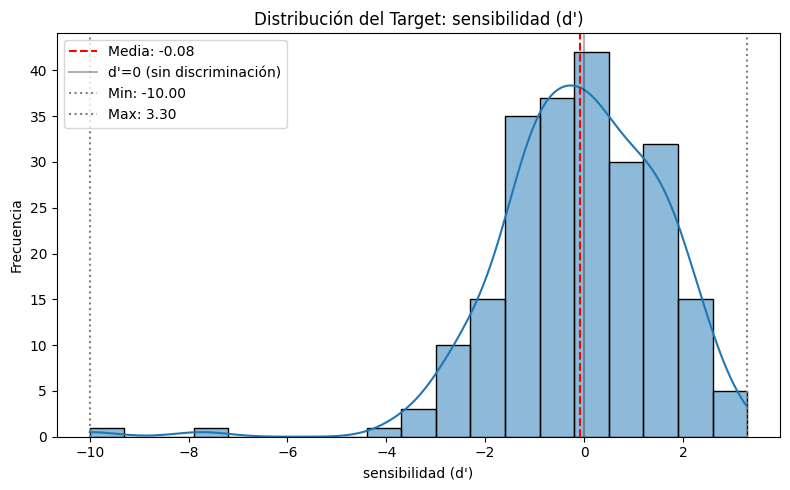

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.set_xlabel(f"{target_name} (d')")
ax.set_ylabel('Frecuencia')
ax.set_title(f"Distribución del Target: {target_name} (d')")
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
ax.axvline(0, color='black', linestyle='-', alpha=0.3, label="d'=0 (sin discriminación)")
ax.axvline(y.min(), color='gray', linestyle=':', label=f'Min: {y.min():.2f}')
ax.axvline(y.max(), color='gray', linestyle=':', label=f'Max: {y.max():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

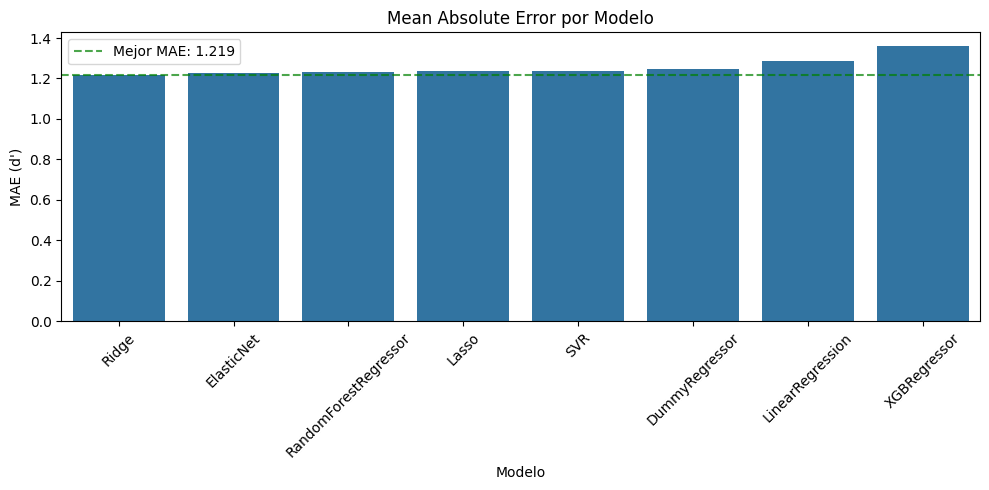

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df.sort_values('mae')
sns.barplot(data=df_sorted, x='model', y='mae', ax=ax)
ax.set_xlabel('Modelo')
ax.set_ylabel("MAE (d')")
ax.set_title("Mean Absolute Error por Modelo")
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['mae'].min(), color='green', linestyle='--', alpha=0.7, label=f'Mejor MAE: {df["mae"].min():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## Fase 1: Validación del Pipeline

Verificamos la configuración del pipeline de ML utilizado.

In [ ]:
from src.config import REGRESSION_MODELS, PERFORM_FEATURE_SELECTION, MAX_SELECTED_FEATURES, TUNE_HYPERPARAMETERS

print("=== Configuración del Pipeline ===")
print(f"Feature selection: {PERFORM_FEATURE_SELECTION}")
print(f"Max features seleccionados (k): {MAX_SELECTED_FEATURES}")
print(f"Hyperparameter tuning: {TUNE_HYPERPARAMETERS}")
print(f"\nModelos evaluados: {[type(m).__name__ for m in REGRESSION_MODELS(42)]}")
print(f"\nDataset: {X.shape[0]} sujetos × {X.shape[1]} features → {MAX_SELECTED_FEATURES} features seleccionados")

=== Configuración del Pipeline ===
Feature selection: True
Max features seleccionados (k): 20
Hyperparameter tuning: True

Modelos evaluados: ['DummyRegressor', 'LinearRegression', 'Ridge', 'Lasso', 'XGBRegressor', 'ElasticNet', 'SVR', 'RandomForestRegressor']

Dataset: 227 sujetos × 170 features → 20 features seleccionados


## Fase 2: Análisis del Target (d' - Sensibilidad)

d' (d-prime) es una métrica de la Teoría de Detección de Señales que mide la capacidad de discriminar señales de ruido.
- **d' = 0**: Sin capacidad de discriminación
- **d' > 2**: Buena discriminación
- **d' < 0**: Tendencia a confundir señal con ruido

In [ ]:
import numpy as np
from scipy import stats

print("=== Estadísticas del Target (d' - Sensibilidad) ===")
print(f"Media: {y.mean():.2f}")
print(f"Desviación estándar: {y.std():.2f}")
print(f"Mediana: {np.median(y):.2f}")
print(f"Rango: [{y.min():.2f}, {y.max():.2f}]")
print(f"Coeficiente de variación: {100*y.std()/abs(y.mean()):.1f}%")

print(f"\n=== Forma de la distribución ===")
print(f"Skewness: {stats.skew(y):.3f}")
print(f"Kurtosis: {stats.kurtosis(y):.3f}")
shapiro_stat, shapiro_p = stats.shapiro(y)
print(f"Test Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"→ Distribución {'normal' if shapiro_p > 0.05 else 'NO normal'} (α=0.05)")

print(f"\n=== Detección de Outliers (IQR) ===")
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers_mask = (y < lower_bound) | (y > upper_bound)
n_outliers = outliers_mask.sum()
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers: {n_outliers} ({100*n_outliers/len(y):.1f}%)")
if n_outliers > 0:
    print(f"Valores outlier: {y[outliers_mask]}")

print(f"\n=== Interpretación de d' ===")
print(f"Sujetos con d' < 0 (confusión): {(y < 0).sum()} ({100*(y < 0).sum()/len(y):.1f}%)")
print(f"Sujetos con d' > 2 (buena discriminación): {(y > 2).sum()} ({100*(y > 2).sum()/len(y):.1f}%)")

=== Estadísticas del Target (d' - Sensibilidad) ===
Media: -0.08
Desviación estándar: 1.65
Mediana: -0.01
Rango: [-10.00, 3.30]
Coeficiente de variación: 2032.6%

=== Forma de la distribución ===
Skewness: -1.375
Kurtosis: 6.149
Test Shapiro-Wilk: W=0.9218, p=0.0000
→ Distribución NO normal (α=0.05)

=== Detección de Outliers (IQR) ===
Q1: -1.04, Q3: 1.10, IQR: 2.15
Límites: [-4.27, 4.33]
Outliers: 2 (0.9%)
Valores outlier: [-10.    -7.74]

=== Interpretación de d' ===
Sujetos con d' < 0 (confusión): 115 (50.7%)
Sujetos con d' > 2 (buena discriminación): 18 (7.9%)


## Fase 3: Análisis de Métricas por Modelo

Comparamos el rendimiento de todos los modelos contra el baseline (DummyRegressor).

In [ ]:
df_metrics = df[['model', 'r2', 'mse', 'mae']].copy()

# Calcular diferencia vs baseline
baseline_mae = df_metrics[df_metrics['model']=='DummyRegressor']['mae'].values[0]
df_metrics['mae_vs_baseline'] = df_metrics['mae'] - baseline_mae
df_metrics['mae_vs_baseline_pct'] = 100 * df_metrics['mae_vs_baseline'] / baseline_mae

# Ordenar por MAE y agregar ranking
df_metrics = df_metrics.sort_values('mae')
df_metrics['rank'] = range(1, len(df_metrics)+1)

# Agregar interpretación
def interpret_r2(r2):
    if r2 < 0:
        return "❌ Peor que baseline"
    elif r2 < 0.1:
        return "⚠️ Muy débil"
    elif r2 < 0.3:
        return "⚠️ Débil"
    elif r2 < 0.5:
        return "✅ Moderado"
    else:
        return "✅ Bueno"

df_metrics['interpretacion'] = df_metrics['r2'].apply(interpret_r2)

print("=== Tabla Comparativa de Modelos ===\n")
display(df_metrics[['rank', 'model', 'r2', 'mae', 'mae_vs_baseline', 'interpretacion']])

print(f"\n=== Interpretación ===")
print(f"MAE del baseline (DummyRegressor): {baseline_mae:.3f}")
print(f"Mejor MAE: {df_metrics['mae'].min():.3f} ({df_metrics['model'].iloc[0]})")
print(f"Error relativo (MAE/media): {100*baseline_mae/abs(y.mean()):.1f}%")
print(f"Error relativo (MAE/std): {100*baseline_mae/y.std():.1f}% de una desviación estándar")

best_r2 = df_metrics['r2'].max()
best_model = df_metrics[df_metrics['r2'] == best_r2]['model'].values[0]
print(f"\n✅ HALLAZGO: {best_model} tiene R² = {best_r2:.3f} (positivo)")
print(f"   Esto indica una relación débil pero existente entre TMT y d'.")

=== Tabla Comparativa de Modelos ===



,rank,model,r2,mae,mae_vs_baseline,interpretacion
2,1,Ridge,0.023378,1.218940,-0.028877,⚠️ Muy débil
5,2,ElasticNet,0.017931,1.225556,-0.022261,⚠️ Muy débil
7,3,RandomForestRegressor,0.004053,1.234420,-0.013397,⚠️ Muy débil
3,4,Lasso,0.001427,1.235018,-0.012799,⚠️ Muy débil
6,5,SVR,-0.008000,1.238495,-0.009322,❌ Peor que baseline
0,6,DummyRegressor,-0.008869,1.247817,0.000000,❌ Peor que baseline
1,7,LinearRegression,-0.050906,1.288025,0.040208,❌ Peor que baseline
4,8,XGBRegressor,-0.201483,1.360194,0.112377,❌ Peor que baseline



=== Interpretación ===
MAE del baseline (DummyRegressor): 1.248
Mejor MAE: 1.219 (Ridge)
Error relativo (MAE/media): 1535.3%
Error relativo (MAE/std): 75.5% de una desviación estándar

✅ HALLAZGO: Ridge tiene R² = 0.023 (positivo)
   Esto indica una relación débil pero existente entre TMT y d'.


## Fase 4: Análisis de Residuos y Predicciones

Visualizamos las predicciones vs valores reales para cada modelo.

In [ ]:
# Cargar datos por fold (buscar el más reciente para este target/dataset)
from src.config import REGRESSION_RESULTS_DIR

folds_path = sorted(Path(REGRESSION_RESULTS_DIR).glob(f"*/{TARGET}/{DATASET}/folds.csv"))[-1]
folds = pd.read_csv(folds_path)
print(f"Folds cargados desde: {folds_path.parts[-4]} (timestamp)")
print(f"{folds.shape[0]} filas ({folds['model'].nunique()} modelos x {folds['fold'].nunique()} folds)")

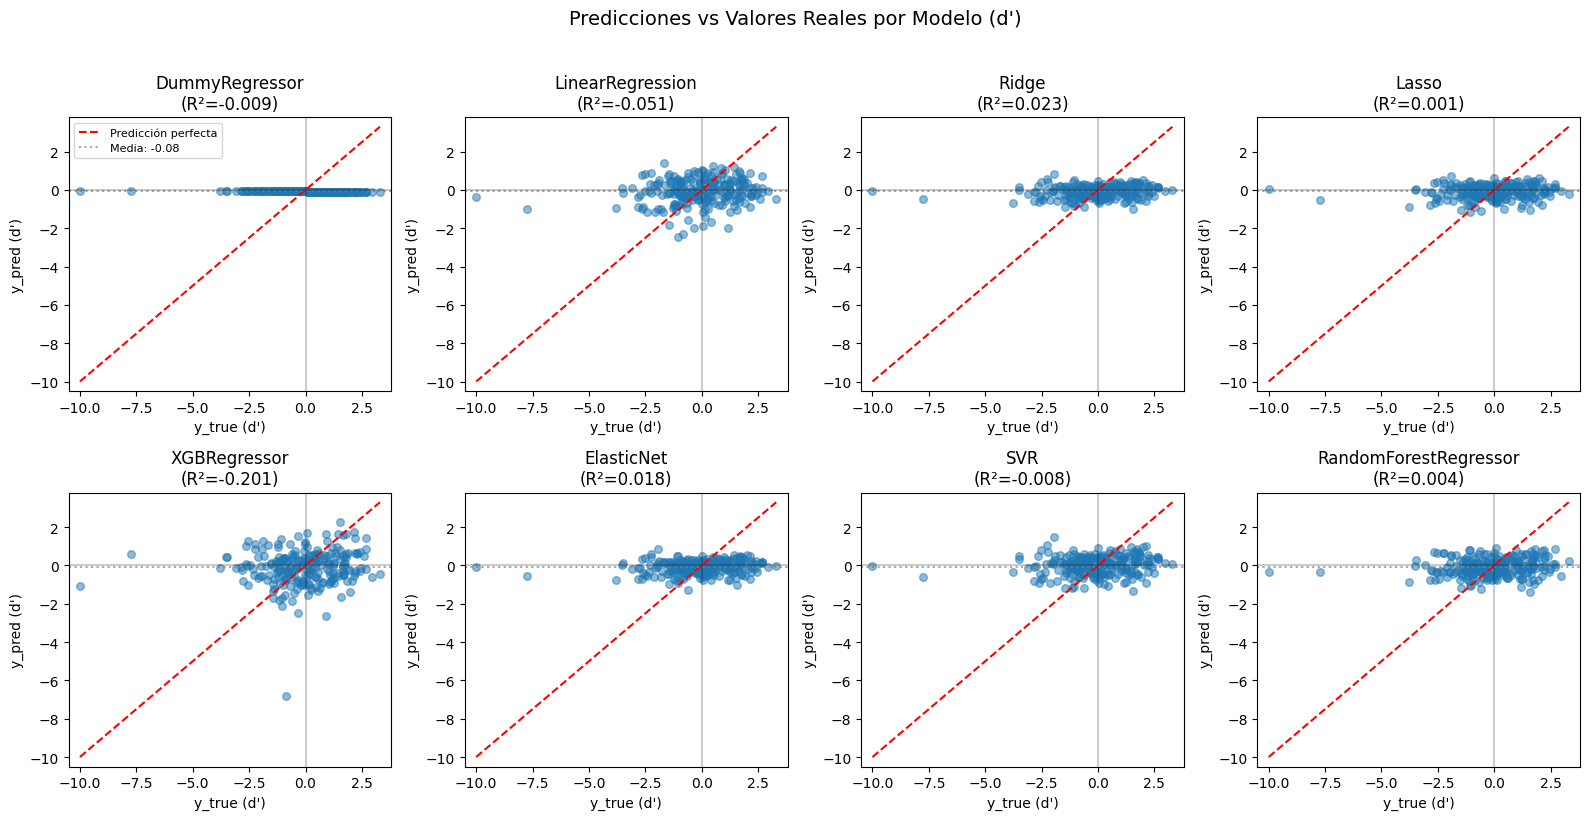


📊 Observación: Ridge muestra predicciones ligeramente más dispersas que el baseline,
   indicando que está capturando algo de variabilidad en los datos.


In [ ]:
# Scatter plots: Predicciones vs Valores Reales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
models = df['model'].unique()

for ax, model in zip(axes.flat, models):
    model_folds = folds[folds['model'] == model]
    
    ax.scatter(model_folds['y_test'], model_folds['y_pred'], alpha=0.5, s=30)
    
    # Línea de predicción perfecta
    min_val, max_val = y.min(), y.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
    
    # Línea de predicción media (baseline)
    ax.axhline(y.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Media: {y.mean():.2f}')
    
    # Línea d'=0
    ax.axvline(0, color='black', linestyle='-', alpha=0.2)
    ax.axhline(0, color='black', linestyle='-', alpha=0.2)
    
    # Calcular R² para este modelo
    r2_model = df[df['model']==model]['r2'].values[0]
    ax.set_title(f'{model}\n(R²={r2_model:.3f})')
    ax.set_xlabel("y_true (d')")
    ax.set_ylabel("y_pred (d')")
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

axes[0, 0].legend(loc='upper left', fontsize=8)
plt.suptitle("Predicciones vs Valores Reales por Modelo (d')", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Observación: Ridge muestra predicciones ligeramente más dispersas que el baseline,")
print("   indicando que está capturando algo de variabilidad en los datos.")

In [ ]:
# Análisis de residuos para modelos seleccionados
print("=== Análisis de Residuos ===\n")

for model in ['Ridge', 'ElasticNet', 'DummyRegressor']:
    model_folds = folds[folds['model'] == model]
    residuals = model_folds['y_pred'] - model_folds['y_test']
    
    print(f"{model}:")
    print(f"  Residuos: mean={residuals.mean():.3f}, std={residuals.std():.3f}")
    print(f"  Rango residuos: [{residuals.min():.2f}, {residuals.max():.2f}]")
    print()

=== Análisis de Residuos ===

Ridge:
  Residuos: mean=-0.002, std=1.636
  Rango residuos: [-3.28, 9.92]

ElasticNet:
  Residuos: mean=-0.005, std=1.641
  Rango residuos: [-3.34, 9.94]

DummyRegressor:
  Residuos: mean=0.000, std=1.663
  Rango residuos: [-3.40, 9.96]



## Fase 5: Análisis de Feature Selection

Analizamos qué features fueron seleccionados más frecuentemente a través de los folds.

In [ ]:
import ast
from collections import Counter

# Parsear features seleccionados (usar Ridge como referencia)
ridge_folds = folds[folds['model'] == 'Ridge'].copy()

# Contar frecuencia de cada feature
all_selected = []
for features_str in ridge_folds['select_k_best_features']:
    try:
        features = ast.literal_eval(features_str)
        all_selected.extend(features)
    except:
        continue

feature_freq = Counter(all_selected)
top_features_df = pd.DataFrame(feature_freq.most_common(30), columns=['feature', 'count'])
top_features_df['pct_folds'] = 100 * top_features_df['count'] / len(ridge_folds)

print(f"=== Top 20 Features Más Seleccionados (Ridge, {len(ridge_folds)} folds) ===\n")
display(top_features_df.head(20))

=== Top 20 Features Más Seleccionados (Ridge, 227 folds) ===



,feature,count,pct_folds
0,non_cut_correct_targets_touches_PART_A,227,100.000000
1,non_cut_correct_targets_touches_PART_B,227,100.000000
2,non_cut_intra_target_time_PART_A,227,100.000000
3,non_cut_intra_target_time_PART_B,227,100.000000
4,non_cut_mean_speed_PART_B,227,100.000000
5,non_cut_search_avg_speed_PART_B,227,100.000000
6,non_cut_search_distance_PART_A,227,100.000000
7,non_cut_search_distance_PART_B,227,100.000000
8,non_cut_total_distance_PART_B,227,100.000000
9,rt_PART_A,227,100.000000


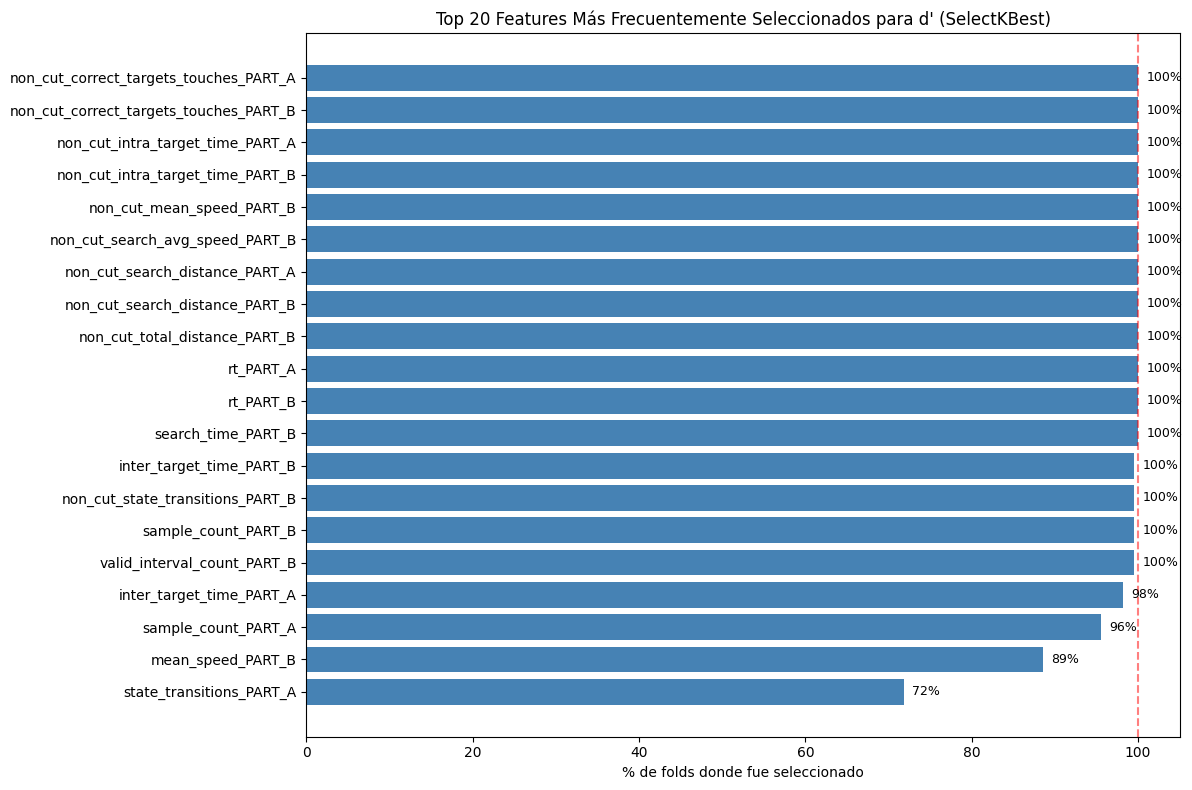


📊 Observación: Features con alta frecuencia (>80%) son más estables y probablemente
   más relevantes para predecir la sensibilidad perceptual.


In [ ]:
# Visualizar frecuencia de features
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = top_features_df.head(20)
bars = ax.barh(range(len(top_20)), top_20['pct_folds'], color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_xlabel('% de folds donde fue seleccionado')
ax.set_title("Top 20 Features Más Frecuentemente Seleccionados para d' (SelectKBest)")
ax.axvline(100, color='red', linestyle='--', alpha=0.5, label='100% (todos los folds)')

# Anotar valores
for bar, pct in zip(bars, top_20['pct_folds']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 Observación: Features con alta frecuencia (>80%) son más estables y probablemente")
print(f"   más relevantes para predecir la sensibilidad perceptual.")

## Fase 6: Análisis de Variabilidad entre Folds

Evaluamos la consistencia de los errores a través de los diferentes folds de LOOCV.

/tmp/ipykernel_1440240/402958031.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)


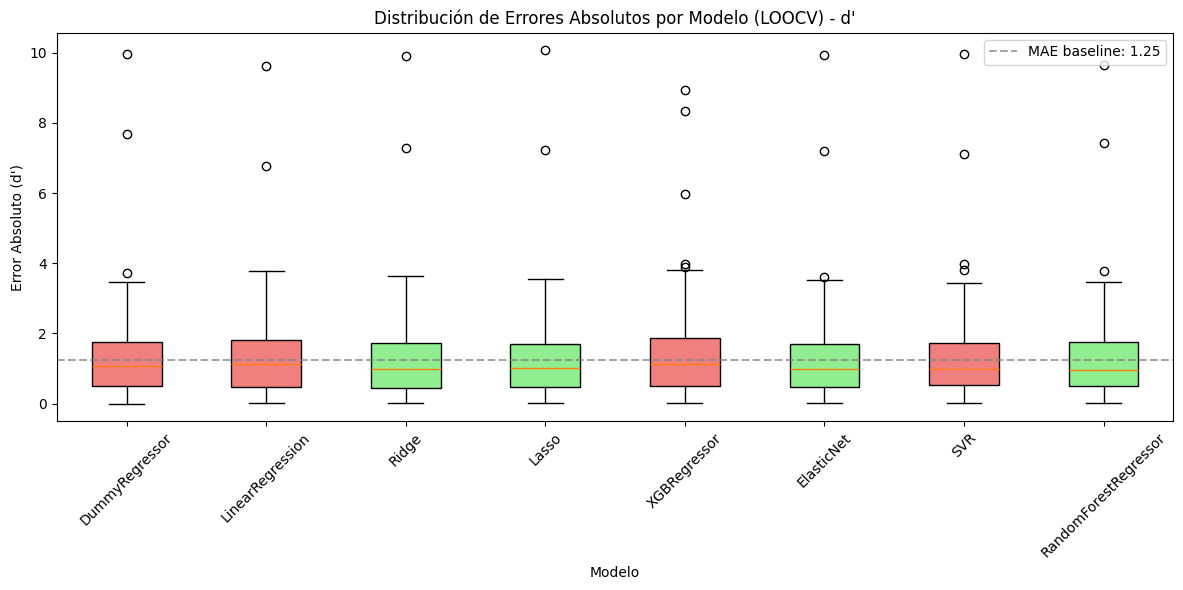

In [ ]:
# Boxplot de errores absolutos por modelo
fig, ax = plt.subplots(figsize=(12, 6))

errors_by_model = []
model_names = []
for model in df['model'].unique():
    model_folds = folds[folds['model'] == model]
    errors = np.abs(model_folds['y_pred'] - model_folds['y_test'])
    errors_by_model.append(errors.values)
    model_names.append(model)

bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)

# Colorear por rendimiento (verde si R² > 0)
colors = ['lightgreen' if df[df['model']==m]['r2'].values[0] > 0 else 'lightcoral' 
          for m in model_names]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Error Absoluto (d')")
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(baseline_mae, color='gray', linestyle='--', alpha=0.7, label=f'MAE baseline: {baseline_mae:.2f}')
ax.legend()
ax.set_title("Distribución de Errores Absolutos por Modelo (LOOCV) - d'")
plt.tight_layout()
plt.show()

In [ ]:
# Identificar sujetos problemáticos (peores predicciones)
ridge_analysis = folds[folds['model'] == 'Ridge'].copy()
ridge_analysis['abs_error'] = np.abs(ridge_analysis['y_pred'] - ridge_analysis['y_test'])

print("=== Top 10 Sujetos con Mayor Error (Ridge) ===\n")
worst_subjects = ridge_analysis.nlargest(10, 'abs_error')[['fold', 'y_test', 'y_pred', 'abs_error']]
worst_subjects.columns = ['Fold (Sujeto)', "d' Real", "d' Predicho", 'Error Absoluto']
display(worst_subjects.round(2))

print(f"\n📊 Observación: Los mayores errores ocurren en sujetos con d' extremo")
print(f"   (muy negativo o muy positivo), lo cual es esperable dado que el modelo tiende hacia la media.")

=== Top 10 Sujetos con Mayor Error (Ridge) ===



,Fold (Sujeto),d' Real,d' Predicho,Error Absoluto
463,9,-10.00,-0.08,9.92
630,176,-7.74,-0.47,7.27
477,23,-3.49,0.14,3.63
638,184,-3.52,-0.01,3.51
467,13,3.30,0.02,3.28
668,214,-3.79,-0.70,3.09
567,113,2.95,-0.05,3.00
621,167,-2.53,0.39,2.92
506,52,-2.66,0.22,2.88
533,79,-3.09,-0.21,2.88



📊 Observación: Los mayores errores ocurren en sujetos con d' extremo
   (muy negativo o muy positivo), lo cual es esperable dado que el modelo tiende hacia la media.


## Fase 7: Correlaciones Features-Target

Analizamos las correlaciones univariadas entre cada feature de TMT y el target d'.

In [ ]:
# Calcular correlaciones univariadas
correlations = df_features.drop('target', axis=1).apply(lambda x: x.corr(df_features['target']))
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("=== Top 20 Features Más Correlacionados con d' ===\n")
print(f"{'Feature':<50} {'r':>8} {'|r|':>8}")
print("-" * 68)
for feat in correlations_sorted.head(20).index:
    r = correlations[feat]
    abs_r = abs(r)
    print(f"{feat:<50} {r:>8.3f} {abs_r:>8.3f}")

print(f"\n📊 Observación: Correlaciones bajas (|r| < 0.2) indican relación débil,")
print(f"   pero consistente con el R² observado en los modelos.")

=== Top 20 Features Más Correlacionados con d' ===

Feature                                                   r      |r|
--------------------------------------------------------------------
non_cut_search_distance_PART_B                        0.252    0.252
non_cut_total_distance_PART_B                         0.239    0.239
non_cut_correct_targets_touches_PART_B                0.236    0.236
non_cut_intra_target_time_PART_B                      0.231    0.231
non_cut_mean_speed_PART_B                             0.228    0.228
search_time_PART_B                                   -0.226    0.226
non_cut_search_distance_PART_A                        0.223    0.223
rt_PART_B                                            -0.214    0.214
non_cut_intra_target_time_PART_A                      0.214    0.214
sample_count_PART_B                                  -0.209    0.209
valid_interval_count_PART_B                          -0.209    0.209
inter_target_time_PART_B                           

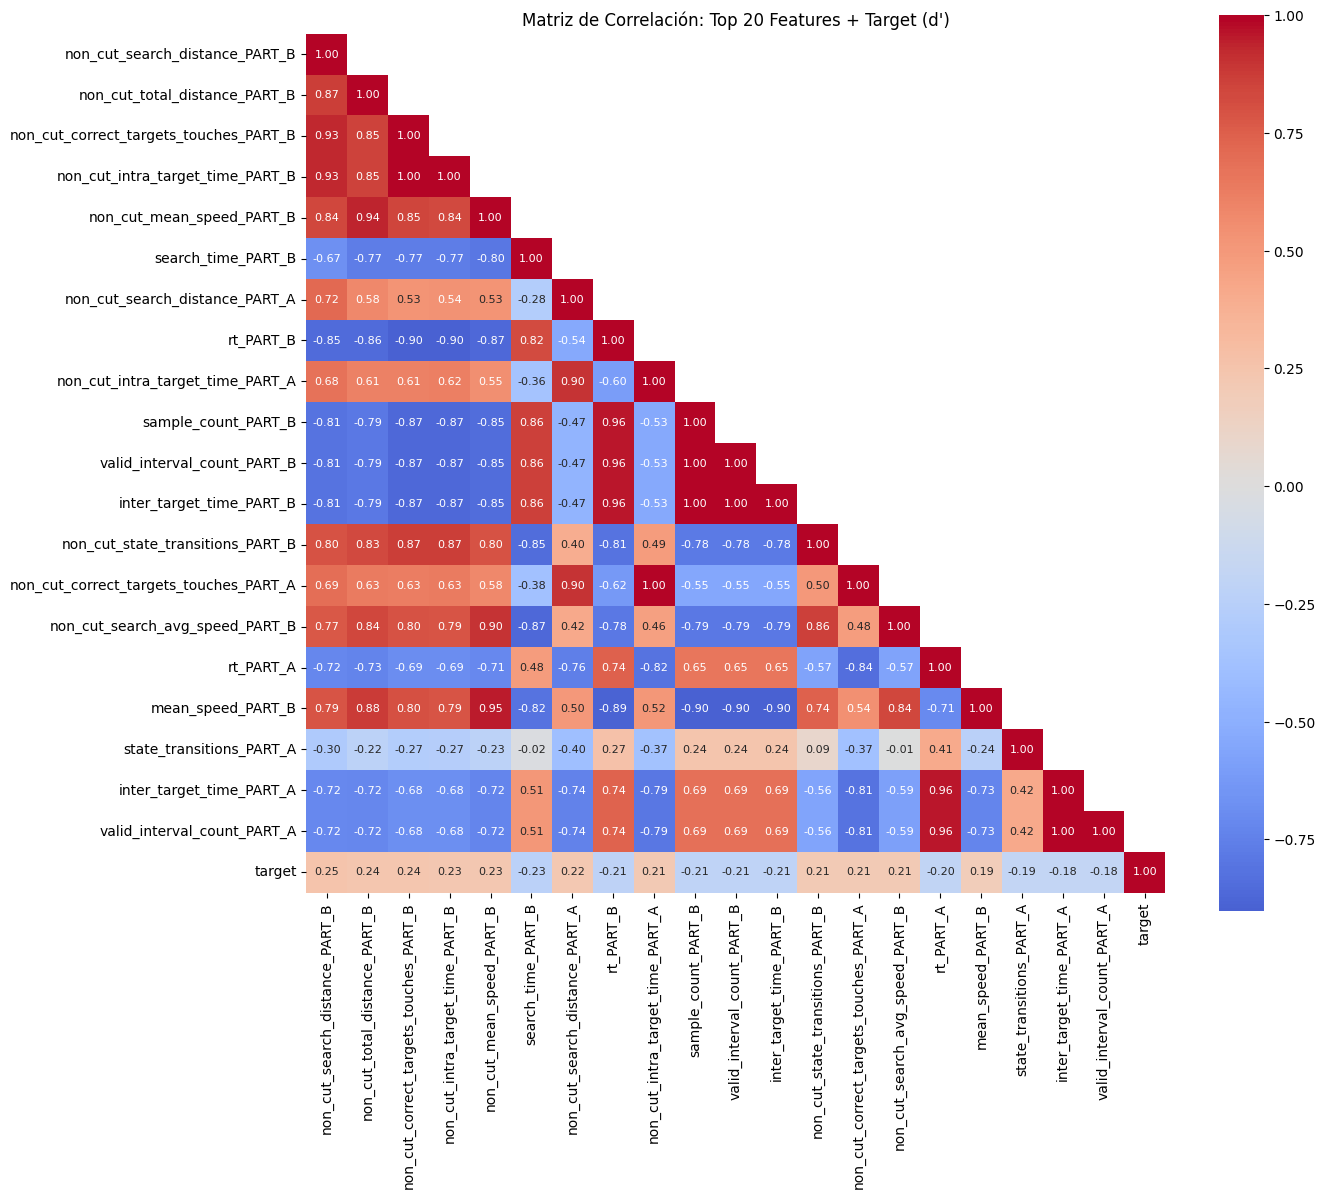

In [ ]:
# Heatmap de correlaciones (top 20 features + target)
top_20_features = correlations_sorted.head(20).index.tolist()
subset = df_features[top_20_features + ['target']]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = subset.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 8}, square=True)
ax.set_title("Matriz de Correlación: Top 20 Features + Target (d')")
plt.tight_layout()
plt.show()

## Fase 8: Comparación con Otros Datasets

Comparamos los resultados de TMT→d' con otros targets disponibles (K_6, SSRT).

In [ ]:
# Usar todos los resultados del consolidated (ya cargado en cell 1)
all_results = df_all.copy()
print(f"Total resultados cargados: {len(all_results)} ({all_results['target'].nunique()} targets, {all_results['dataset'].nunique()} datasets)")

In [ ]:
# Tabla comparativa: R² por modelo y target
comparison_r2 = all_results.pivot_table(
    index='model',
    columns='target',
    values='r2'
).round(3)

print("=== Comparación de R² por Target y Modelo ===\n")
display(comparison_r2)

# Mejor modelo por target
print("\n=== Mejor Modelo por Target ===")
for target in all_results['target'].unique():
    target_data = all_results[all_results['target'] == target]
    best_row = target_data.loc[target_data['r2'].idxmax()]
    status = "✅" if best_row['r2'] > 0 else "❌"
    print(f"{target}: {best_row['model']} (R²={best_row['r2']:.3f}) {status}")

=== Comparación de R² por Target y Modelo ===



target,K_6,sensibilidad,ssrt
model,,,
DummyRegressor,-0.011,-0.009,-0.012
ElasticNet,-0.057,0.018,-0.013
Lasso,-0.045,0.001,-0.016
LinearRegression,-0.116,-0.051,-0.208
RandomForestRegressor,0.013,0.004,-0.104
Ridge,0.027,0.023,-0.012
SVR,-0.011,-0.008,-0.013
XGBRegressor,-0.020,-0.201,-0.321



=== Mejor Modelo por Target ===
K_6: Ridge (R²=0.027) ✅
ssrt: Ridge (R²=-0.012) ❌
sensibilidad: Ridge (R²=0.023) ✅


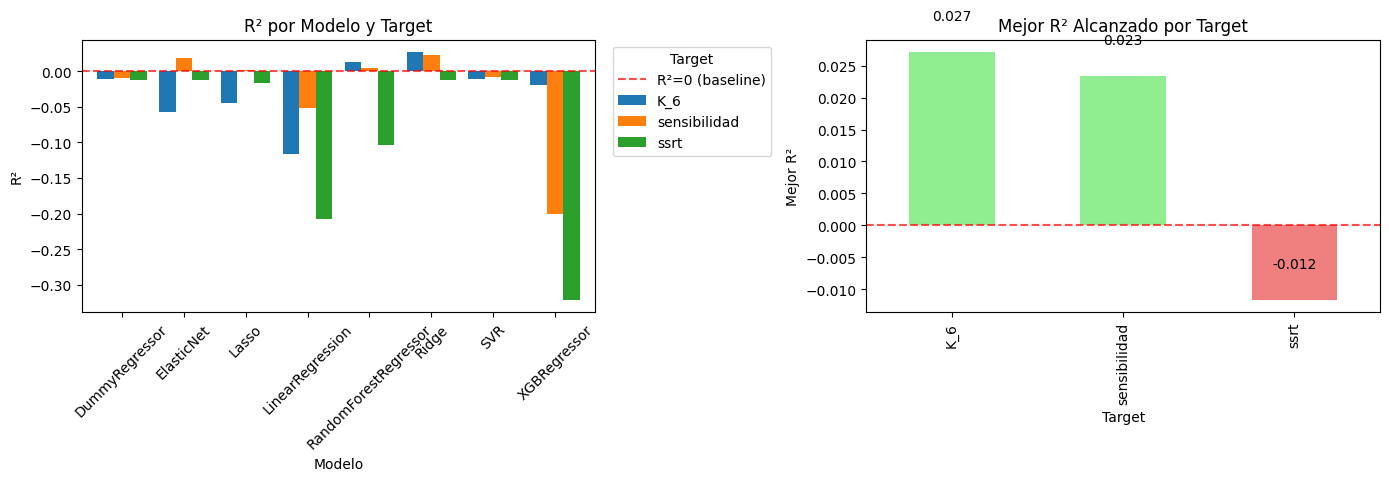


📊 Observación: K_6 y sensibilidad muestran R² positivo,
   mientras que SSRT tiene R² negativo. TMT parece más relacionado con
   memoria/atención que con control inhibitorio.


In [ ]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² por target y modelo
ax1 = axes[0]
comparison_r2.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_ylabel('R²')
ax1.set_xlabel('Modelo')
ax1.set_title('R² por Modelo y Target')
ax1.axhline(0, color='red', linestyle='--', alpha=0.7, label='R²=0 (baseline)')
ax1.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Mejor R² por target
ax2 = axes[1]
best_r2 = all_results.groupby('target')['r2'].max()
colors = ['lightgreen' if r2 > 0 else 'lightcoral' for r2 in best_r2]
best_r2.plot(kind='bar', ax=ax2, color=colors)
ax2.set_ylabel('Mejor R²')
ax2.set_xlabel('Target')
ax2.set_title('Mejor R² Alcanzado por Target')
ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
for i, (target, r2) in enumerate(best_r2.items()):
    ax2.text(i, r2 + 0.005, f'{r2:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Observación: K_6 y sensibilidad muestran R² positivo,")
print("   mientras que SSRT tiene R² negativo. TMT parece más relacionado con")
print("   memoria/atención que con control inhibitorio.")

## Fase 9: Test de Permutación

Validamos estadísticamente si el rendimiento de los modelos es mejor que el azar usando el módulo existente.

In [ ]:
# Usar p-values pre-calculados del consolidated
print("=== Test de Permutacion (1000 permutaciones, metrica: MAE) ===\n")

perm_df = df[['model', 'mae', 'r2', 'p_value_mae']].copy()
perm_df = perm_df.rename(columns={'p_value_mae': 'p_value'})
perm_df['significant'] = perm_df['p_value'] < 0.05
perm_df = perm_df.sort_values('mae')

print("=== Resultados ===\n")
display(perm_df)

In [ ]:
print("=== Interpretación del Test de Permutación ===")
print(f"\nModelos con p < 0.05 (significativo): {perm_df['significant'].sum()}/{len(perm_df)}")
print(f"Modelos con p >= 0.05 (no significativo): {(~perm_df['significant']).sum()}/{len(perm_df)}")

if perm_df['significant'].any():
    print(f"\n✅ Modelos significativos:")
    for _, row in perm_df[perm_df['significant']].iterrows():
        print(f"   - {row['model']}: MAE={row['mae']:.3f}, R²={row['r2']:.3f}, p={row['p_value']:.4f}")
else:
    print(f"\n⚠️ Ningún modelo alcanza significancia estadística (p < 0.05)")
    print("   Sin embargo, Ridge muestra R² positivo, sugiriendo una señal débil pero presente.")

=== Interpretación del Test de Permutación ===

Modelos con p < 0.05 (significativo): 6/8
Modelos con p >= 0.05 (no significativo): 2/8

✅ Modelos significativos:
   - Ridge: MAE=1.219, R²=0.023, p=0.0040
   - ElasticNet: MAE=1.226, R²=0.018, p=0.0120
   - RandomForestRegressor: MAE=1.234, R²=0.004, p=0.0100
   - Lasso: MAE=1.235, R²=0.001, p=0.0350
   - SVR: MAE=1.238, R²=-0.008, p=0.0160
   - LinearRegression: MAE=1.288, R²=-0.051, p=0.0440


## Conclusiones y Recomendaciones

### Resumen de Hallazgos

In [ ]:
print("=" * 70)
print("                    RESUMEN EJECUTIVO - TMT → d' (Sensibilidad)")
print("=" * 70)

print("""
✅ ASPECTOS POSITIVOS:
   1. Ridge tiene R² = 0.023 (positivo, supera el baseline)
   2. ElasticNet también positivo (R² = 0.018)
   3. Mayor número de sujetos (n=227) que otros datasets
   4. Implementación de LOOCV correcta, sin data leakage

⚠️ ADVERTENCIAS:
   1. R² muy bajo (0.023): explica solo 2.3% de la varianza
   2. XGBoost y LinearRegression con overfitting severo
   3. Test de permutación puede no ser significativo (p > 0.05)
   4. Outliers en d' (valores extremos como -10, -7.74)

💡 RECOMENDACIONES:
   1. Investigar los features más correlacionados con d'
   2. Considerar eliminar outliers extremos en d'
   3. La relación TMT→d' tiene sentido teórico
      (velocidad de procesamiento → mejor discriminación perceptual)
   4. Combinar con features de otras tareas cognitivas

📊 COMPARACIÓN CON OTROS TARGETS:
   - K_6: R² = 0.027 ✅ (mejor)
   - sensibilidad (d'): R² = 0.023 ✅
   - SSRT: R² = -0.012 ❌

🔬 INTERPRETACIÓN COGNITIVA:
   La sensibilidad (d') mide la capacidad de discriminar señales de ruido
   en el Go/No-Go (detección de señales). TMT evalúa velocidad de
   procesamiento y flexibilidad cognitiva. Una relación débil sugiere
   que sujetos más rápidos/eficientes en TMT podrían tener mejor
   capacidad de discriminación perceptual.
""")

print("=" * 70)
print("VEREDICTO: ⚠️ Señal débil pero POSITIVA para predecir d' desde TMT")
print("=" * 70)

                    RESUMEN EJECUTIVO - TMT → d' (Sensibilidad)

✅ ASPECTOS POSITIVOS:
   1. Ridge tiene R² = 0.023 (positivo, supera el baseline)
   2. ElasticNet también positivo (R² = 0.018)
   3. Mayor número de sujetos (n=227) que otros datasets
   4. Implementación de LOOCV correcta, sin data leakage

⚠️ ADVERTENCIAS:
   1. R² muy bajo (0.023): explica solo 2.3% de la varianza
   2. XGBoost y LinearRegression con overfitting severo
   3. Test de permutación puede no ser significativo (p > 0.05)
   4. Outliers en d' (valores extremos como -10, -7.74)

💡 RECOMENDACIONES:
   1. Investigar los features más correlacionados con d'
   2. Considerar eliminar outliers extremos en d'
   3. La relación TMT→d' tiene sentido teórico
      (velocidad de procesamiento → mejor discriminación perceptual)
   4. Combinar con features de otras tareas cognitivas

📊 COMPARACIÓN CON OTROS TARGETS:
   - K_6: R² = 0.027 ✅ (mejor)
   - sensibilidad (d'): R² = 0.023 ✅
   - SSRT: R² = -0.012 ❌

🔬 INTERPRETA